# 🏠 House Price Prediction using Linear Regression

# 📌 Objective
Predict House prices using:
- Living Area (GrLivArea)
- Number of Bedrooms (BedroomAbvGr)
- Number of Bathrooms (FullBath)

---

# 🛠️ Tech Stack
- Python
- Pandas
- Scikit-learn
- Matplotlib

In [14]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [15]:
## 📥 Load Dataset

In [16]:
# Load dataset
df = pd.read_csv(r"C:\House Price Prediction\data\train.csv")

# Preview data
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [17]:
## 📊 Data Understanding

In [18]:
# Check info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [19]:
# Select required columns
features = ["GrLivArea", "BedroomAbvGr", "FullBath"]
target = "SalePrice"

df = df[features + [target]]

df.head()

,GrLivArea,BedroomAbvGr,FullBath,SalePrice
0,1710,3,2,208500
1,1262,3,2,181500
2,1786,3,2,223500
3,1717,3,1,140000
4,2198,4,2,250000


In [20]:
## 🧹 Data Cleaning

In [21]:
# Handle missing values
df = df.fillna(df.mean())

In [22]:
## 📈 Data Visualization

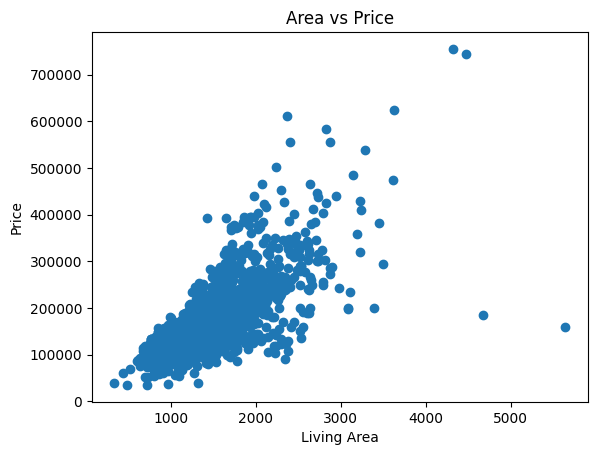

In [23]:
# Area vs Price
plt.figure()
plt.scatter(df["GrLivArea"], df["SalePrice"])
plt.xlabel("Living Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

In [24]:
## ✂️ Train-Test Split

In [25]:
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
## ⚙️ Feature Scaling

In [27]:
## 🤖 Model Training

In [28]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
## 📉 Model Evaluation

In [30]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 2806426667.247853
R2 Score: 0.6341189942328371


In [31]:
## 📊 Actual vs Predicted

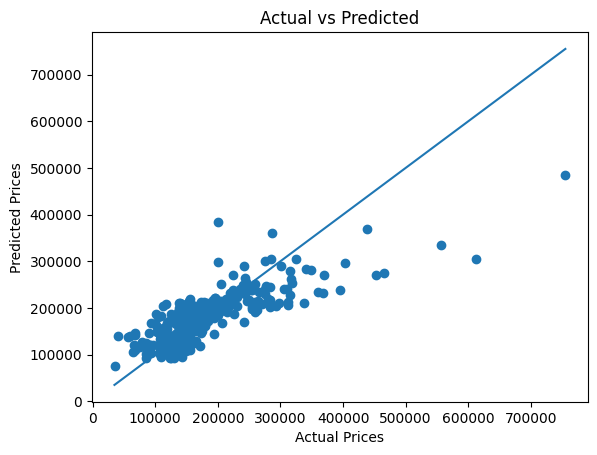

In [32]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")

plt.plot([y.min(), y.max()], [y.min(), y.max()])

plt.show()

In [33]:
## 🔍 Feature Importance

In [34]:
coeff_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

coeff_df

,Feature,Coefficient
0,GrLivArea,104.026307
1,BedroomAbvGr,-26655.165357
2,FullBath,30014.324109


In [35]:
## 🏡 Predict New House Price

In [47]:
# Example: 2000 sqft, 3 bedrooms, 2 bathrooms
features = ["GrLivArea", "BedroomAbvGr", "FullBath"]

new_house = pd.DataFrame(
    [[2000, 3, 2]],
    columns=features
)

new_house_scaled = scaler.transform(new_house)
new_house_scaled = pd.DataFrame(new_house_scaled, columns=features)
prediction = model.predict(new_house_scaled)

print("Predicted Price:", prediction[0])

Predicted Price: 71695.67088800919
